# E-commerce orders — Exploratory Data Analysis (for unsupervised anomaly detection)

**Goal:** understand `orders-sheet.csv` (~150k rows, **no fraud label**) well enough to make good decisions about feature engineering and model choice later. **No model is trained here.**

Layout: every step = a markdown cell (*what it shows* / *why it matters for anomalies*) + code. Per-column charts are grouped into a single grid cell so all columns can be compared at a glance.

Sections: 1 Overview & data quality · 2 Column identification · 3 Univariate · 4 Bivariate/multivariate · 5 Customer & product behaviour · 6 Outlier preview · 7 Summary

## 0. Setup
**What:** imports, plotting style, load the CSV, define column groups, a 20k-row sample for scatter plots, and a small grid helper.
**Why:** scatter plots with 150k points are slow and unreadable (overplotting) — a fixed random sample keeps them fast and reproducible. Histograms/boxplots use the full data.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 10, "axes.labelsize": 9, "figure.autolayout": False})
pd.options.display.max_columns = 60
pd.options.display.float_format = "{:,.2f}".format

PATH = "orders-sheet.csv"
raw = pd.read_csv(PATH)

id_cols  = ["order_id", "customer_id", "product_id", "product_name"]
num_cols = ["customer_age", "account_age_days", "quantity", "unit_price", "discount_pct",
            "shipping_cost", "tax_amount", "platform_fee", "order_value"]
money_cols = ["unit_price", "shipping_cost", "tax_amount", "platform_fee", "order_value"]
cat_cols = ["customer_country", "ip_country", "category", "payment_method", "sales_channel",
            "device_type", "order_status", "coupon_used"]

def grid(n, ncols=3, h=3.2, w=5.6):
    """Create a grid of n axes (extra axes hidden). Returns fig, flat axes array."""
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]: ax.set_visible(False)
    return fig, axes

SAMPLE_N = 20_000
print(raw.shape)

(150000, 22)


# 1. Overview and data quality

### 1.1 Shape, dtypes, memory, head/tail
**What:** size of the data, type of each column, RAM footprint, first/last rows.
**Why:** wrong dtypes (e.g. dates as strings, numbers as objects) silently break later feature code; head/tail catches obviously broken rows early.

In [2]:
print("shape:", raw.shape)
print(f"memory: {raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "n_unique": raw.nunique(), "example": raw.iloc[0]}))
display(raw.head())
display(raw.tail())

shape: (150000, 22)
memory: 121.7 MB


,dtype,n_unique,example
order_id,object,74002,ORD0020474
order_timestamp,object,137953,2025-09-12 02:16:00
customer_id,object,17997,C009777
customer_country,object,10,France
customer_age,float64,58,52.00
account_age_days,int64,2993,806
product_id,object,1200,P01005
product_name,object,1200,HOM Product 1005
category,object,20,Home
quantity,int64,83,1


,order_id,order_timestamp,customer_id,customer_country,customer_age,account_age_days,product_id,product_name,category,quantity,unit_price,discount_pct,shipping_cost,tax_amount,platform_fee,order_value,payment_method,sales_channel,device_type,ip_country,order_status,coupon_used
0,ORD0020474,2025-09-12 02:16:00,C009777,France,52.00,806,P01005,HOM Product 1005,Home,1,22.74,20.00,5.37,0.25,2.79,23.81,PayPal,Mobile App,Android,Italy,Shipped,No
1,ORD0051725,2026-01-12 19:59:00,C000463,UK,59.00,2842,P00133,ELE Product 0133,Electronics,1,60.97,50.00,0.00,4.84,4.56,35.33,Card,Web,Android,Ireland,Cancelled,No
2,ORD0052945,2025-03-18 18:35:00,C012549,Germany,72.00,2074,P00692,TOY Product 0692,Toys,2,54.74,0.00,5.59,1.80,17.33,116.87,Card,Marketplace,NaN,UK,Completed,No
3,ORD0087395,2025-08-28 19:34:00,C008297,US,45.00,430,P00372,TOO Product 0372,Tools,1,41.99,0.00,2.36,4.40,3.72,48.75,Card,Mobile App,Android,UK,Completed,No
4,ORD0010652,2026-06-14 15:34:00,C006144,Italy,54.00,1130,P00624,SPO Product 0624,Sports,2,10.44,25.00,8.40,2.13,1.19,26.19,Apple Pay,Web,Desktop,UK,Completed,No


,order_id,order_timestamp,customer_id,customer_country,customer_age,account_age_days,product_id,product_name,category,quantity,unit_price,discount_pct,shipping_cost,tax_amount,platform_fee,order_value,payment_method,sales_channel,device_type,ip_country,order_status,coupon_used
149995,ORD0065598,2026-09-23 11:03:00,C006078,UK,72.00,269,P01007,OFF Product 1007,Office,3,17.69,0.00,7.44,1.41,6.17,61.92,Apple Pay,Web,Android,UK,Shipped,No
149996,ORD0056942,2025-03-24 16:46:00,C012744,US,28.00,933,P00727,TOY Product 0727,Toys,4,69.15,50.00,4.45,1.19,10.41,143.94,Card,Mobile App,Android,UK,Pending,No
149997,ORD0084532,2025-11-14 08:14:00,C001208,US,55.00,52,P00897,BEA Product 0897,Beauty,1,4.25,0.00,3.50,0.17,0.39,7.92,Card,Web,NaN,UK,Completed,Yes
149998,ORD0066541,2026-08-09 19:57:00,C009528,Ireland,75.00,601,P01122,ELE Product 1122,Electronics,1,7.24,20.00,1.99,0.59,0.79,8.37,PayPal,Marketplace,Android,UK,Completed,No
149999,ORD0078683,2025-06-09 22:20:00,C010713,UK,62.00,2449,P00682,HOM Product 0682,Home,2,167.89,10.00,6.40,2.55,36.88,311.15,Bank Transfer,Web,Desktop,NaN,Completed,Yes


### 1.2 Missing values
**What:** % of missing cells per column + bar chart.
**Why:** missingness itself can be a signal (e.g. missing `device_type`/`ip_country` on a risky order) — decide per column whether to impute, flag, or drop.

,missing_%,missing_n
device_type,1.80,2703
customer_age,1.20,1802
ip_country,0.90,1347
discount_pct,0.60,900
shipping_cost,0.40,601


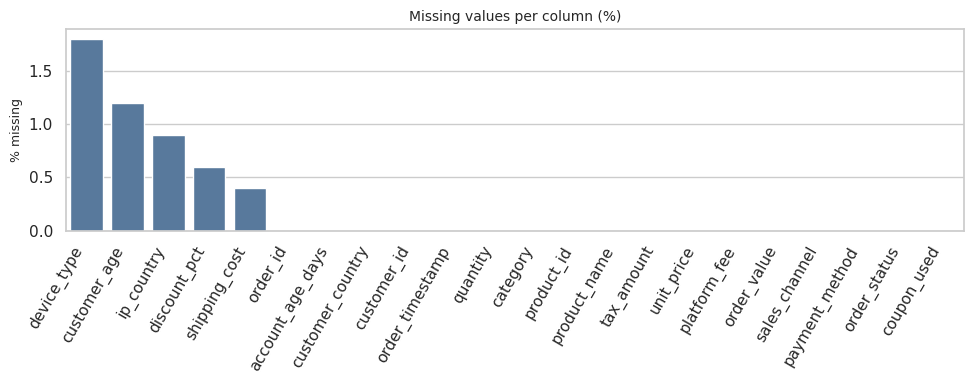

In [3]:
miss = (raw.isna().mean() * 100).rename("missing_%")
miss_tbl = pd.concat([miss, raw.isna().sum().rename("missing_n")], axis=1).sort_values("missing_%", ascending=False)
display(miss_tbl[miss_tbl["missing_n"] > 0])
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=miss_tbl.index, y=miss_tbl["missing_%"], color="#4C78A8", ax=ax)
ax.set_title("Missing values per column (%)"); ax.set_ylabel("% missing"); ax.set_xlabel("")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

### 1.3 Duplicates (full rows vs repeated order IDs)
**What:** counts of fully identical rows, and of repeated `order_id`s — then a look at what repeated IDs actually are.
**Why:** exact duplicates are either data-pipeline errors (drop) or *replayed orders* (suspicious). Repeated IDs can be multi-line orders (same customer/time, different products) **or** ID collisions (unrelated rows sharing an ID) — the table below tells which. We need to know which before deciding the unit of analysis (row vs order).

In [4]:
print("fully duplicated rows        :", raw.duplicated().sum())
print("rows with a repeated order_id:", raw["order_id"].duplicated(keep=False).sum())
print("unique order_ids / rows      :", raw["order_id"].nunique(), "/", len(raw))
g = raw.groupby("order_id")
dup_ids = g.size()[lambda s: s > 1].index
sub = raw[raw["order_id"].isin(dup_ids)]
gs = sub.groupby("order_id")
summary = pd.DataFrame({
    "rows_per_id": gs.size(),
    "n_customers": gs["customer_id"].nunique(),
    "n_products": gs["product_id"].nunique(),
    "n_timestamps": gs["order_timestamp"].nunique(),
})
print("\nrows per repeated order_id:"); display(summary["rows_per_id"].value_counts().to_frame("n_order_ids"))
print("share of repeated IDs where ... is identical across rows:")
display(pd.Series({"same customer": (summary.n_customers == 1).mean(),
                   "same product": (summary.n_products == 1).mean(),
                   "same timestamp": (summary.n_timestamps == 1).mean()}).to_frame("share"))
print("example repeated-ID groups:")
display(sub.sort_values(["order_id", "order_timestamp"]).head(12))
print("example fully-duplicated rows:")
display(raw[raw.duplicated(keep=False)].sort_values("order_id").head(8))

fully duplicated rows        : 350
rows with a repeated order_id: 120477
unique order_ids / rows      : 74002 / 150000

rows per repeated order_id:


,n_order_ids
rows_per_id,
2,23873
3,12879
4,5369
5,1727
6,470
7,127
8,32
9,2


share of repeated IDs where ... is identical across rows:


,share
same customer,0.00
same product,0.00
same timestamp,0.00


example repeated-ID groups:


,order_id,order_timestamp,customer_id,customer_country,customer_age,account_age_days,product_id,product_name,category,quantity,unit_price,discount_pct,shipping_cost,tax_amount,platform_fee,order_value,payment_method,sales_channel,device_type,ip_country,order_status,coupon_used
147336,ORD0000002,2025-07-01 12:18:00,C001616,UK,72.00,2520,P00181,GAR Product 0181,Garden,89,728.40,20.00,11.91,10.64,7.04,"70,073.63",PayPal,Web,Android,US,Shipped,No
149707,ORD0000002,2025-10-01 13:06:00,C017170,US,63.00,365,P00261,TOY Product 0261,Toys,1,115.00,5.00,6.79,5.89,11.94,121.93,Card,Mobile App,iPhone,US,Cancelled,No
130693,ORD0000003,2025-05-02 06:00:00,C007178,Germany,67.00,2852,P00979,FAS Product 0979,Fashion,1,19.15,15.00,3.82,3.08,2.01,23.18,Card,Mobile App,iPhone,Netherlands,Shipped,No
65171,ORD0000003,2026-01-12 16:08:00,C013885,Germany,51.00,762,P00515,GAR Product 0515,Garden,1,33.76,0.00,9.48,2.14,4.14,45.38,Bank Transfer,Mobile App,Android,US,Completed,No
44306,ORD0000004,2025-01-19 09:45:00,C005727,UK,50.00,722,P00509,AUT Product 0509,Automotive,2,23.18,0.00,9.41,2.42,4.12,58.19,PayPal,Web,Android,Netherlands,Pending,No
123643,ORD0000004,2025-05-06 21:43:00,C017095,US,32.00,2070,P00924,HOM Product 0924,Home,40,"1,449.33",20.00,6.68,2.97,2.92,"66,290.80",Card,Web,Android,Spain,Shipped,No
7711,ORD0000004,2026-05-25 23:53:00,C005389,US,26.00,2069,P00201,FAS Product 0201,Fashion,2,48.90,5.00,2.02,8.73,12.54,103.66,Apple Pay,Web,iPhone,Germany,Completed,No
79299,ORD0000005,2026-07-19 07:48:00,C017835,France,22.00,802,P00151,OFF Product 0151,Office,3,60.30,0.00,7.52,16.12,28.62,204.54,Google Pay,Web,iPhone,Spain,Completed,Yes
22090,ORD0000005,2026-07-26 18:36:00,C015213,US,24.00,87,P00143,AUT Product 0143,Automotive,4,11.66,20.00,3.23,6.71,5.55,47.25,Card,Web,Android,Italy,Completed,No
131170,ORD0000006,2025-03-27 19:46:00,C010630,Canada,61.00,2107,P00260,BEA Product 0260,Beauty,1,26.87,0.00,0.37,1.75,3.39,28.99,PayPal,Web,Android,Netherlands,Refunded,No


example fully-duplicated rows:


,order_id,order_timestamp,customer_id,customer_country,customer_age,account_age_days,product_id,product_name,category,quantity,unit_price,discount_pct,shipping_cost,tax_amount,platform_fee,order_value,payment_method,sales_channel,device_type,ip_country,order_status,coupon_used
17514,ORD0000537,2025-03-26 04:41:00,C014948,UK,51.00,2976,P00502,TOO Product 0502,Tools,1,19.80,5.00,7.58,1.84,2.40,28.23,PayPal,Web,Desktop,US,Pending,Yes
20611,ORD0000537,2025-03-26 04:41:00,C014948,UK,51.00,2976,P00502,TOO Product 0502,Tools,1,19.80,5.00,7.58,1.84,2.40,28.23,PayPal,Web,Desktop,US,Pending,Yes
14670,ORD0000585,2026-02-19 00:11:00,C001009,UK,28.00,2212,P01194,TOY Product 1194,Toys,2,19.50,0.00,4.80,4.44,3.05,48.24,Card,Web,iPhone,Germany,Cancelled,No
109177,ORD0000585,2026-02-19 00:11:00,C001009,UK,28.00,2212,P01194,TOY Product 1194,Toys,2,19.50,0.00,4.80,4.44,3.05,48.24,Card,Web,iPhone,Germany,Cancelled,No
5803,ORD0000700,2025-02-21 12:51:00,C010010,UK,29.00,2068,P00466,GAR Product 0466,Garden,1,54.43,10.00,13.11,8.80,5.38,70.90,PayPal,Web,Desktop,Australia,Shipped,No
102318,ORD0000700,2025-02-21 12:51:00,C010010,UK,29.00,2068,P00466,GAR Product 0466,Garden,1,54.43,10.00,13.11,8.80,5.38,70.90,PayPal,Web,Desktop,Australia,Shipped,No
9464,ORD0000945,2025-05-12 18:27:00,C011367,UK,64.00,2757,P01103,GAR Product 1103,Garden,1,25.32,0.00,6.97,1.38,3.65,33.67,PayPal,Web,iPhone,UK,Completed,No
114430,ORD0000945,2025-05-12 18:27:00,C011367,UK,64.00,2757,P01103,GAR Product 1103,Garden,1,25.32,0.00,6.97,1.38,3.65,33.67,PayPal,Web,iPhone,UK,Completed,No


### 1.4 Parse dates, date range, orders per day / week / month
**What:** convert `order_timestamp` to datetime; line charts of order counts at three granularities.
**Why:** anomaly models need time features (hour/day), and volume spikes/drops/gaps reveal ingestion problems or bursts of fraudulent activity. The partial first/last period often shows a fake dip — ignore the edges.

unparseable timestamps: 0
range: 2025-01-01 00:02:00 -> 2026-09-30 23:58:00 (637 days)


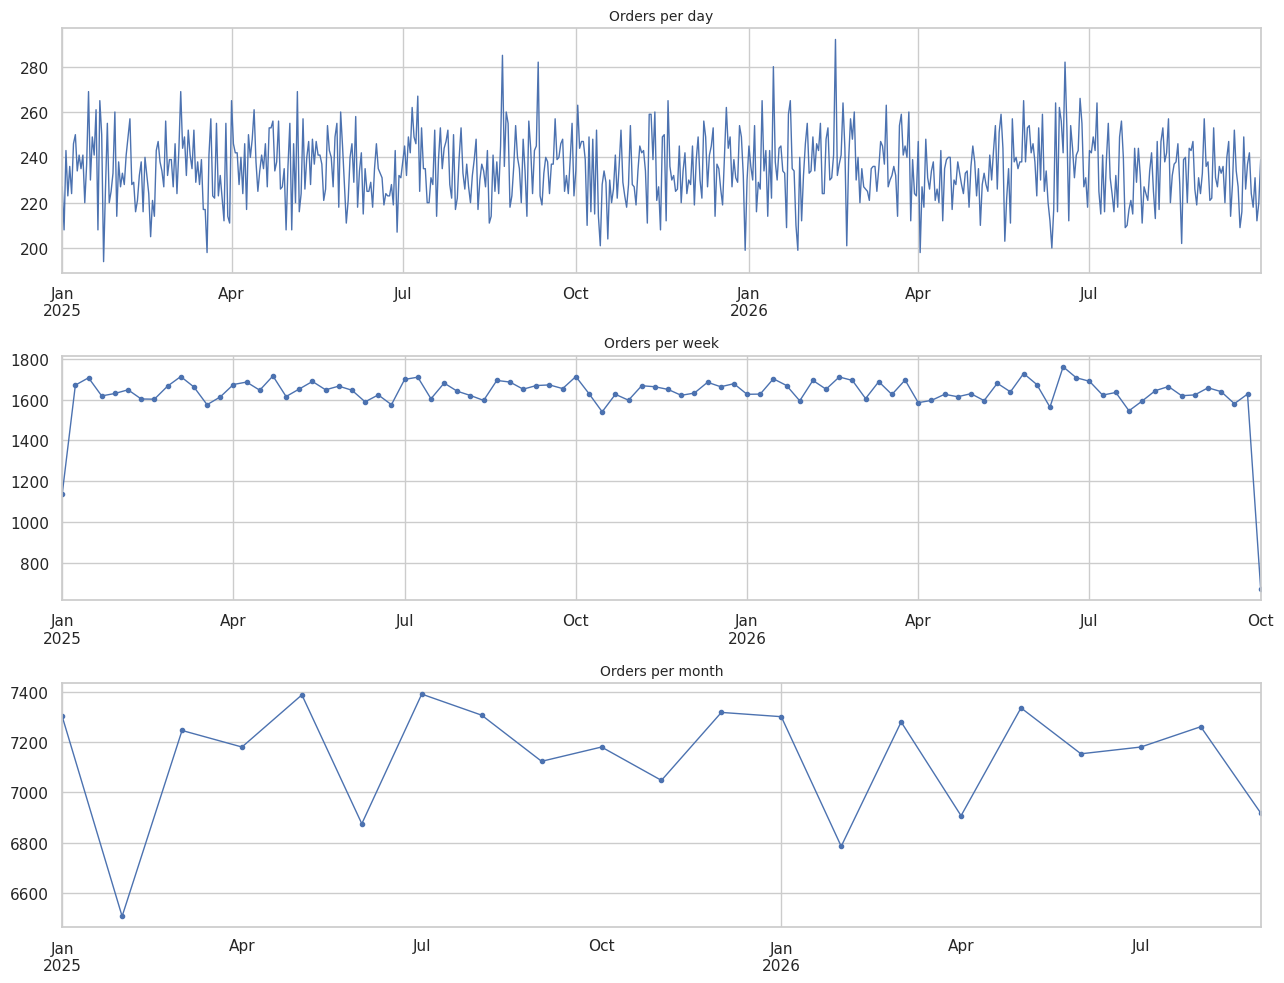

In [5]:
raw["ts"] = pd.to_datetime(raw["order_timestamp"], errors="coerce")
print("unparseable timestamps:", raw["ts"].isna().sum())
print("range:", raw["ts"].min(), "->", raw["ts"].max(), f"({(raw['ts'].max()-raw['ts'].min()).days} days)")
s = raw.set_index("ts").sort_index()
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, (rule, name) in zip(axes, [("D", "day"), ("W", "week"), ("MS", "month")]):
    s.resample(rule).size().plot(ax=ax, marker="." if rule != "D" else None, lw=1)
    ax.set_title(f"Orders per {name}"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### 1.5 Odd values: negatives, zeros, impossible values, inconsistent formats
**What:** per numeric column count of negatives / zeros / NaN; domain rules (age, discount, quantity); label inconsistencies (case/whitespace) in categoricals; ID format check.
**Why:** garbage values are not the same as *interesting* anomalies — we must separate data errors (clean) from genuinely unusual orders (keep). Dirty labels (`paypal` vs `PayPal`) would otherwise create fake rare categories that an anomaly model would flag.

In [6]:
odd = pd.DataFrame({
    "negative": (raw[num_cols] < 0).sum(),
    "zero": (raw[num_cols] == 0).sum(),
    "nan": raw[num_cols].isna().sum(),
    "min": raw[num_cols].min(), "max": raw[num_cols].max(),
})
display(odd)

rules = {
    "customer_age < 18": (raw.customer_age < 18).sum(),
    "customer_age > 100": (raw.customer_age > 100).sum(),
    "discount_pct >= 100": (raw.discount_pct >= 100).sum(),
    "discount_pct > 50": (raw.discount_pct > 50).sum(),
    "quantity <= 0": (raw.quantity <= 0).sum(),
    "quantity > 20": (raw.quantity > 20).sum(),
    "unit_price <= 0": (raw.unit_price <= 0).sum(),
    "order_value <= 0": (raw.order_value <= 0).sum(),
    "account_age_days < 0": (raw.account_age_days < 0).sum(),
    "customer_age not whole number": (raw.customer_age.dropna() % 1 != 0).sum(),
}
print("Domain-rule violations:"); display(pd.Series(rules).to_frame("rows"))

rows = []
for c in cat_cols:
    v = raw[c].dropna().astype(str)
    rows.append({"column": c, "raw_unique": v.nunique(), "unique_after_strip_lower": v.str.strip().str.lower().nunique(),
                 "rows_with_whitespace": (v != v.str.strip()).sum()})
display(pd.DataFrame(rows))
print("Labels that are variants of another label:")
for c in cat_cols:
    v = raw[c].dropna().astype(str)
    k = v.str.strip().str.lower()
    var = v.groupby(k).agg(lambda x: dict(x.value_counts()))
    var = var[var.map(len) > 1]
    if len(var): print(f"  {c}:", dict(var))

print("ID format ok (regex):",
      {"order_id": raw.order_id.str.match(r"^ORD\d+$").mean(), "customer_id": raw.customer_id.str.match(r"^C\d+$").mean(),
       "product_id": raw.product_id.str.match(r"^P\d+$").mean()})

,negative,zero,nan,min,max
customer_age,0,0,1802,18.00,75.00
account_age_days,0,77,0,0.00,"2,999.00"
quantity,0,0,0,1.00,99.00
unit_price,0,0,0,1.00,"1,799.84"
discount_pct,0,74185,900,0.00,95.00
shipping_cost,0,7770,601,0.00,899.39
tax_amount,0,159,0,0.00,741.92
platform_fee,0,0,0,0.09,637.18
order_value,0,0,0,1.23,"200,028.66"


Domain-rule violations:


,rows
customer_age < 18,0
customer_age > 100,0
discount_pct >= 100,0
discount_pct > 50,543
quantity <= 0,0
quantity > 20,539
unit_price <= 0,0
order_value <= 0,0
account_age_days < 0,0
customer_age not whole number,0


,column,raw_unique,unique_after_strip_lower,rows_with_whitespace
0,customer_country,10,10,0
1,ip_country,10,10,0
2,category,20,10,0
3,payment_method,6,5,0
4,sales_channel,4,3,299
5,device_type,4,4,0
6,order_status,5,5,0
7,coupon_used,2,2,0


Labels that are variants of another label:
  category: {'automotive': {'Automotive': np.int64(12358), 'automotive': np.int64(28)}, 'beauty': {'Beauty': np.int64(15883), 'beauty': np.int64(33)}, 'electronics': {'Electronics': np.int64(14432), 'electronics': np.int64(24)}, 'fashion': {'Fashion': np.int64(12582), 'fashion': np.int64(28)}, 'garden': {'Garden': np.int64(15134), 'garden': np.int64(26)}, 'home': {'Home': np.int64(16833), 'home': np.int64(27)}, 'office': {'Office': np.int64(14541), 'office': np.int64(26)}, 'sports': {'Sports': np.int64(16895), 'sports': np.int64(31)}, 'tools': {'Tools': np.int64(14733), 'tools': np.int64(32)}, 'toys': {'Toys': np.int64(16309), 'toys': np.int64(45)}}
  payment_method: {'paypal': {'PayPal': np.int64(49221), 'paypal': np.int64(301)}}
  sales_channel: {'web': {'Web': np.int64(68747), 'web ': np.int64(299)}}
ID format ok (regex): {'order_id': np.float64(1.0), 'customer_id': np.float64(1.0), 'product_id': np.float64(1.0)}


### 1.6 Clean working copy `d`
**What:** strip + canonicalise categorical labels (variants map to the most frequent spelling), add `date/hour/dow` features. **Exact duplicate rows are kept** (flag `is_dup_row`) so you can decide later.
**Why:** all analysis below uses the cleaned frame so rare-category / outlier results are not polluted by typos.

In [7]:
d = raw.copy()
for c in cat_cols:
    v = d[c].astype("string").str.strip()
    canon = v.groupby(v.str.lower()).agg(lambda x: x.value_counts().idxmax())
    d[c] = v.str.lower().map(canon)
d["is_dup_row"] = d.duplicated(subset=[c for c in raw.columns if c != "ts"], keep="first")
d["hour"] = d.ts.dt.hour; d["dow"] = d.ts.dt.dayofweek; d["date"] = d.ts.dt.date
print({c: d[c].nunique() for c in cat_cols})

{'customer_country': 10, 'ip_country': 10, 'category': 10, 'payment_method': 5, 'sales_channel': 3, 'device_type': 4, 'order_status': 5, 'coupon_used': 2}


# 2. Column identification

### 2.1 `describe()` of all numeric columns
**What:** count, mean, std, min, quartiles and extreme percentiles (1%, 99%, 99.9%).
**Why:** compare **mean vs median** and **99.9% vs max** — a huge gap = heavy tail / suspicious extreme values. The column names here are descriptive, so the next cells *verify* what each money column does rather than guess.

In [8]:
display(d[num_cols].describe(percentiles=[.01, .25, .5, .75, .99, .999]).T)

,count,mean,std,min,1%,25%,50%,75%,99%,99.9%,max
customer_age,"148,198.00",46.60,16.69,18.00,18.00,32.00,47.00,61.00,75.00,75.00,75.00
account_age_days,"150,000.00","1,491.34",868.34,0.00,19.00,739.00,"1,491.00","2,237.00","2,967.00","2,997.00","2,999.00"
quantity,"150,000.00",2.24,4.26,1.00,1.00,1.00,1.00,2.00,10.00,80.00,99.00
unit_price,"150,000.00",47.83,82.20,1.00,3.14,15.71,29.62,53.34,282.71,"1,417.72","1,799.84"
discount_pct,"149,100.00",9.84,13.77,0.00,0.00,0.00,5.00,15.00,50.00,89.00,95.00
shipping_cost,"149,399.00",8.50,34.66,0.00,0.00,3.83,6.51,9.24,16.43,718.32,899.39
tax_amount,"150,000.00",8.10,16.66,0.00,0.05,1.26,3.35,8.28,74.71,191.15,741.92
platform_fee,"150,000.00",9.45,16.72,0.09,0.36,2.14,4.53,10.03,77.91,192.14,637.18
order_value,"150,000.00",363.93,"4,734.42",1.23,7.97,28.14,51.45,105.67,"1,876.09","87,929.78","200,028.66"


### 2.2 Does `order_value` = qty × price × (1 − discount) + shipping + tax ?  (and where does `platform_fee` fit?)
**What:** we test several candidate formulas for `order_value` and report how many rows match to within 1 cent, plus the residual distribution.
**Why:** if an exact formula holds for ~all rows, then rows that **violate it** are inconsistent/tampered orders — among the strongest anomaly signals — and the residual becomes a great engineered feature. It also tells us which columns are redundant (derived) and which are independent inputs.
**How to read the residual plot:** the big spike at 0 is the 'normal' world; anything off-zero is an order whose total doesn't add up.

,rows_evaluable,match_<=1c_%,median_abs_err,p99_abs_err,max_abs_err
A: sub + ship + tax,"148,502.00",98.56,0.00,944.77,"80,755.58"
B: A + platform_fee,"148,502.00",0.00,4.63,940.38,"80,755.26"
C: A - platform_fee,"148,502.00",0.00,4.63,949.11,"80,755.90"
D: qty*price + ship + tax (no disc),"149,399.00",49.20,0.46,839.11,"25,446.84"
E: sub + tax,"149,100.00",5.15,6.56,968.89,"80,765.17"


rows matching formula A: 97.57%   | rows NOT matching: 2142  | residual NaN (missing discount/shipping): 1498


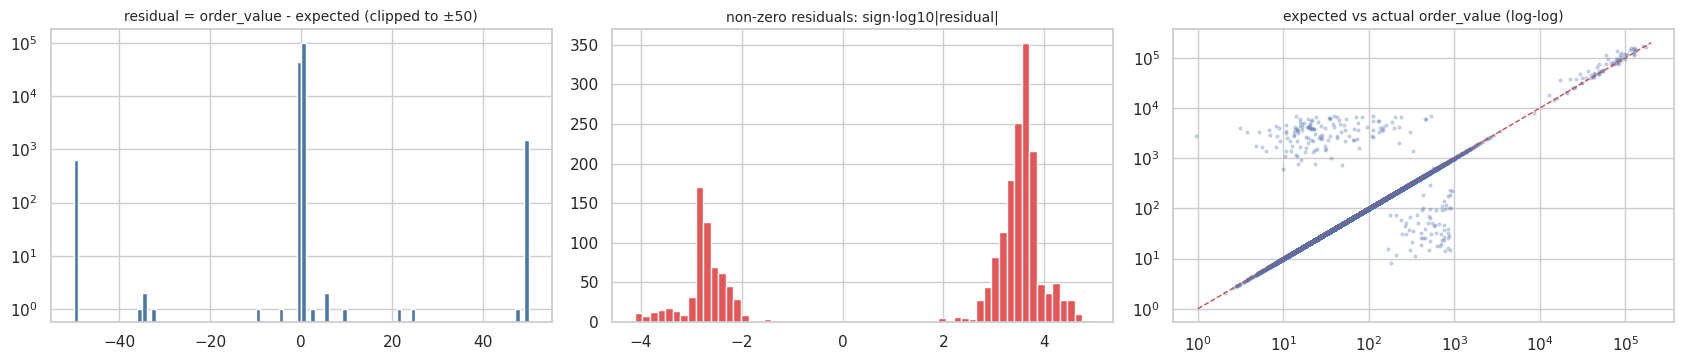

Largest formula violations:


,order_id,customer_id,quantity,unit_price,discount_pct,shipping_cost,tax_amount,platform_fee,order_value,expected_value,residual,order_status
118978,ORD0033650,C011702,99,"1,388.95",50.00,9.59,0.66,0.32,"149,518.86","68,763.28","80,755.58",Shipped
101272,ORD0063362,C016128,94,"1,649.35",30.00,0.85,1.80,0.77,"173,627.20","108,529.88","65,097.32",Completed
15413,ORD0058967,C007531,86,"1,467.26",50.00,6.37,0.75,2.30,"123,197.58","63,099.30","60,098.28",Shipped
30507,ORD0065308,C001407,93,"1,417.72",40.00,4.71,25.53,22.11,"134,701.65","79,139.02","55,562.63",Completed
114060,ORD0066875,C006140,80,"1,474.98",50.00,0.00,9.69,11.02,"114,358.99","59,008.89","55,350.10",Refunded
116240,ORD0050424,C000450,98,"1,630.51",30.00,7.53,3.20,9.70,"165,925.11","111,863.72","54,061.39",Shipped
83720,ORD0065217,C007152,64,"1,654.43",40.00,2.07,4.52,3.64,"116,894.59","63,536.70","53,357.89",Shipped
129791,ORD0088462,C017372,76,"1,277.49",50.00,14.12,0.09,0.13,"96,370.03","48,558.83","47,811.20",Cancelled
20259,ORD0018285,C002402,75,"1,161.71",50.00,9.09,8.83,6.79,"91,127.94","43,582.04","47,545.90",Completed
145864,ORD0088823,C007038,83,996.21,40.00,11.34,3.42,5.32,"94,152.26","49,626.02","44,526.24",Completed


In [9]:
q, p, disc = d.quantity, d.unit_price, d.discount_pct
d["subtotal"] = q * p * (1 - disc / 100)                       # after discount, before ship/tax
cands = {
    "A: sub + ship + tax":                d.subtotal + d.shipping_cost + d.tax_amount,
    "B: A + platform_fee":                d.subtotal + d.shipping_cost + d.tax_amount + d.platform_fee,
    "C: A - platform_fee":                d.subtotal + d.shipping_cost + d.tax_amount - d.platform_fee,
    "D: qty*price + ship + tax (no disc)": q * p + d.shipping_cost + d.tax_amount,
    "E: sub + tax":                       d.subtotal + d.tax_amount,
}
res_tbl = {}
for k, e in cands.items():
    r = (e - d.order_value).abs()
    res_tbl[k] = {"rows_evaluable": r.notna().sum(), "match_<=1c_%": (r <= 0.01).sum() / r.notna().sum() * 100,
                  "median_abs_err": r.median(), "p99_abs_err": r.quantile(.99), "max_abs_err": r.max()}
display(pd.DataFrame(res_tbl).T)

d["expected_value"] = cands["A: sub + ship + tax"]
d["residual"] = d.order_value - d.expected_value
d["formula_ok"] = d.residual.abs() <= 0.01
nz = d.residual.dropna()
print(f"rows matching formula A: {d.formula_ok.mean()*100:.2f}%   | rows NOT matching: {(~d.formula_ok & d.residual.notna()).sum()}  | residual NaN (missing discount/shipping): {d.residual.isna().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(17, 3.8))
axes[0].hist(nz.clip(-50, 50), bins=100, color="#4C78A8"); axes[0].set_title("residual = order_value - expected (clipped to ±50)"); axes[0].set_yscale("log")
big = nz[nz.abs() > 0.01]
axes[1].hist(np.sign(big) * np.log10(big.abs()), bins=60, color="#E45756"); axes[1].set_title("non-zero residuals: sign·log10|residual|")
axes[2].scatter(d.expected_value.sample(SAMPLE_N, random_state=0), d.order_value.loc[d.expected_value.sample(SAMPLE_N, random_state=0).index], s=4, alpha=.25)
axes[2].set_xscale("log"); axes[2].set_yscale("log"); axes[2].set_title("expected vs actual order_value (log-log)")
lims = [1, d.order_value.max()]; axes[2].plot(lims, lims, "r--", lw=1)
plt.tight_layout(); plt.show()
print("Largest formula violations:")
display(d.loc[d.residual.abs().sort_values(ascending=False).index[:15],
              ["order_id", "customer_id", "quantity", "unit_price", "discount_pct", "shipping_cost", "tax_amount", "platform_fee", "order_value", "expected_value", "residual", "order_status"]])

### 2.3 What are tax and platform_fee? (rates relative to the subtotal)
**What:** distributions of `tax/subtotal`, `platform_fee/subtotal`, `shipping/subtotal`, effective discount, and `platform_fee` by sales channel.
**Why:** if tax is a consistent % of subtotal, orders with a weird tax rate are suspicious. A fee that varies by channel (e.g. Marketplace) means channel must be considered when judging whether a fee is 'too high'. Ratios are scale-free features, usually better for anomaly models than raw amounts.

In [ ]:
pos = d.subtotal > 0
for name, col in [("tax_rate", "tax_amount"), ("fee_rate", "platform_fee"), ("ship_ratio", "shipping_cost")]:
    d[name] = np.where(pos, d[col] / d.subtotal, np.nan)
rate_cols = ["tax_rate", "fee_rate", "ship_ratio"]
display(d[rate_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T)
fig, axes = plt.subplots(1, 4, figsize=(20, 3.6))
for ax, c in zip(axes[:3], rate_cols):
    ax.hist(d[c].dropna().clip(upper=d[c].quantile(.99)), bins=80, color="#4C78A8"); ax.set_title(f"{c} (clipped at p99)")
sns.boxplot(data=d, x="sales_channel", y="fee_rate", ax=axes[3], showfliers=False); axes[3].set_title("fee_rate by channel (no fliers)")
plt.tight_layout(); plt.show()
display(d.groupby("sales_channel")[["fee_rate", "tax_rate"]].median().rename(columns=lambda c: "median_" + c))

### 2.4 Customer country vs IP country (mismatch rate)
**What:** share of orders where `customer_country != ip_country`, overall and by segment, plus a country × country heatmap (rows = customer country, row-normalised).
**Why:** an IP in a different country than the customer's profile is a classic fraud indicator (account takeover, proxy use). The dataset has **no shipping country**, so `ip_country` is the geo-mismatch field. **How to read the heatmap:** a strong diagonal = most orders match; bright off-diagonal cells = frequent cross-border pairs.

In [ ]:
both = d.dropna(subset=["customer_country", "ip_country"]).copy()
both["geo_mismatch"] = both.customer_country != both.ip_country
print(f"overall mismatch rate: {both.geo_mismatch.mean()*100:.2f}%  (rows with both countries: {len(both):,})")
fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1.5, 1, 1]})
ct = pd.crosstab(both.customer_country, both.ip_country, normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], cbar=False, annot_kws={"size": 7}); axes[0].set_title("P(ip_country | customer_country)")
both.groupby("customer_country").geo_mismatch.mean().sort_values().mul(100).plot.barh(ax=axes[1], color="#4C78A8"); axes[1].set_title("mismatch % by customer country")
seg = pd.concat({c: both.groupby(c).geo_mismatch.mean().mul(100) for c in ["sales_channel", "payment_method", "order_status", "device_type"]})
seg.plot.barh(ax=axes[2], color="#F58518"); axes[2].set_title("mismatch % by segment")
plt.tight_layout(); plt.show()

# 3. Univariate analysis

### 3.1 Histograms of ALL numeric columns (one grid)
**What:** the distribution of every numeric column, linear scale.
**Why:** shows shape (symmetric / skewed / multimodal) and whether a column is discrete. Heavily right-skewed columns (money, quantity) will dominate any distance-based model unless transformed — the next cell shows the log version.

In [ ]:
fig, axes = grid(len(num_cols), ncols=3, h=3)
for ax, c in zip(axes, num_cols):
    v = d[c].dropna()
    ax.hist(v, bins=60, color="#4C78A8"); ax.set_title(f"{c}  (skew={v.skew():.1f})"); ax.set_yscale("log")
fig.suptitle("Histograms (y axis log so the tail is visible)", y=1.0); plt.tight_layout(); plt.show()

### 3.2 Boxplots of ALL numeric columns (one grid)
**What:** box = middle 50 %, whiskers = 1.5×IQR, dots = points beyond whiskers.
**Why:** a quick view of how many points are 'outside normal'. **Caution:** for skewed data the box is squashed against 0 and *many* normal points show as dots — use the log version next to judge.

In [ ]:
fig, axes = grid(len(num_cols), ncols=3, h=2.4)
for ax, c in zip(axes, num_cols):
    sns.boxplot(x=d[c].dropna(), ax=ax, color="#9ecae9", fliersize=1.5); ax.set_title(c); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### 3.3 Log-scale versions for skewed columns (histogram + boxplot grid)
**What:** `log1p(x)` histograms (top) and boxplots (bottom) for columns with skew > 1.
**Why:** after a log transform the bulk becomes bell-shaped and true extremes separate cleanly — this is the transformation we will likely apply before modelling. **How to read:** x = log(1+value); +1 on the axis ≈ ×2.7 in the real value.

In [ ]:
skewed = [c for c in num_cols if d[c].dropna().skew() > 1]
print("skewed columns (skew>1):", skewed)
fig, axes = plt.subplots(2, len(skewed), figsize=(4.2 * len(skewed), 6))
for j, c in enumerate(skewed):
    v = np.log1p(d[c].dropna().clip(lower=0))
    axes[0, j].hist(v, bins=60, color="#54A24B"); axes[0, j].set_title(f"log1p({c})")
    sns.boxplot(x=v, ax=axes[1, j], color="#b5e0a8", fliersize=1.5); axes[1, j].set_xlabel("")
plt.tight_layout(); plt.show()

### 3.4 Top-10 and bottom-10 values of every numeric column
**What:** the 10 largest and 10 smallest values per column.
**Why:** reveals sentinel values (0, 99, 9999), rounded 'fake' values, and how far the extreme is from the rest.

In [ ]:
tb = {}
for c in num_cols:
    v = d[c].dropna()
    tb[c] = pd.DataFrame({"top10": v.nlargest(10).values, "bottom10": v.nsmallest(10).values})
display(pd.concat(tb, axis=1))

### 3.5 Value counts for every categorical column (one grid)
**What:** bar chart of category frequencies (missing shown as `NaN`).
**Why:** rare categories are natural anomaly candidates; very unbalanced columns carry little information; `NaN` bars show how big the missing group is.

In [ ]:
fig, axes = grid(len(cat_cols) , ncols=3, h=3.2)
for ax, c in zip(axes, cat_cols):
    vc = d[c].fillna("NaN").value_counts()
    vc.plot.bar(ax=ax, color="#4C78A8"); ax.set_title(f"{c}  ({d[c].nunique()} levels)"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
plt.tight_layout(); plt.show()
display(pd.concat({c: d[c].fillna("NaN").value_counts(normalize=True).mul(100).round(2) for c in cat_cols}, axis=0).to_frame("%"))

### 3.6 Cardinality of customer_id, product_id, category
**What:** number of unique values and how concentrated rows are on the most frequent ones (rows per ID distribution).
**Why:** high-cardinality IDs cannot be one-hot encoded and are useless raw — but **aggregates per ID** (orders per customer, price spread per product) are valuable. Cardinality decides the encoding strategy.

In [ ]:
card = pd.DataFrame({c: {"unique": d[c].nunique(), "rows_per_value_mean": len(d) / d[c].nunique(),
                          "rows_per_value_max": d[c].value_counts().max(), "singletons": (d[c].value_counts() == 1).sum()}
                     for c in ["customer_id", "product_id", "product_name", "category", "order_id"]}).T
display(card)
fig, axes = plt.subplots(1, 3, figsize=(17, 3.5))
for ax, c in zip(axes, ["customer_id", "product_id", "category"]):
    vc = d[c].value_counts()
    ax.hist(vc.values, bins=50, color="#4C78A8"); ax.set_title(f"rows per {c} (n={len(vc):,})"); ax.set_yscale("log")
plt.tight_layout(); plt.show()
print("product_name <-> product_id one-to-one:", d.groupby("product_id").product_name.nunique().max() == 1 and d.groupby("product_name").product_id.nunique().max() == 1)
print("each product in a single category:", d.groupby("product_id").category.nunique().max() == 1)

# 4. Bivariate and multivariate analysis

### 4.1 Correlation heatmaps (Pearson and Spearman)
**What:** pairwise correlation between numeric columns. Pearson = linear; Spearman = rank-based (robust to outliers/skew).
**Why:** strongly correlated columns are redundant (e.g. `order_value` with its components); a big gap between Pearson and Spearman means a few extreme values drive the linear correlation. **How to read:** ±1 = move together/opposite, 0 = unrelated.

In [ ]:
cn = num_cols + ["residual"]
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, m in zip(axes, ["pearson", "spearman"]):
    sns.heatmap(d[cn].corr(method=m), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8}, cbar=False)
    ax.set_title(m.title())
plt.tight_layout(); plt.show()

### 4.2 Scatter plots (20k random sample, alpha 0.2)
**What:** quantity vs order value, unit price vs quantity, discount vs order value, platform_fee vs order value, plus shipping vs order value and residual vs order value. Log axes where the data spans orders of magnitude.
**Why:** anomalies show up as points far from the main cloud: huge quantity with tiny value, big discount with huge value, fee out of proportion to the order. **How to read:** dense core = normal behaviour; isolated dots = candidates. Straight lines on log-log plots = a proportional relationship (e.g. fee = k × value).

In [ ]:
S = d.sample(SAMPLE_N, random_state=0)
pairs = [("quantity", "order_value", "log", "log"), ("unit_price", "quantity", "log", "log"), ("discount_pct", "order_value", "linear", "log"),
         ("platform_fee", "order_value", "log", "log"), ("shipping_cost", "order_value", "log", "log"), ("order_value", "residual", "log", "symlog")]
fig, axes = grid(len(pairs), ncols=3, h=4)
for ax, (x, y, sx, sy) in zip(axes, pairs):
    ax.scatter(S[x], S[y], s=6, alpha=0.2, color="#4C78A8", edgecolors="none")
    ax.set_xscale(sx); ax.set_yscale(sy, **({"linthresh": 1} if sy == "symlog" else {})); ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(f"{y} vs {x}")
plt.tight_layout(); plt.show()

### 4.3 order_value by category, channel, payment method, device, country (one grid)
**What:** boxplots of `order_value` (log y-axis) per segment.
**Why:** what is 'normal' depends on context — a €500 order may be routine for Electronics but extreme for Beauty. If medians differ a lot across segments, anomaly scoring should use **segment-relative** features (e.g. value / category median).

In [ ]:
segs = ["category", "sales_channel", "payment_method", "device_type", "customer_country"]
fig, axes = grid(len(segs), ncols=3, h=4.2)
for ax, c in zip(axes, segs):
    order = d.groupby(c).order_value.median().sort_values().index
    sns.boxplot(data=d, x=c, y="order_value", order=order, ax=ax, fliersize=1, color="#9ecae9"); ax.set_yscale("log"); ax.set_title(f"order_value by {c}")
    ax.tick_params(axis="x", rotation=60); ax.set_xlabel("")
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
plt.tight_layout(); plt.show()

### 4.4 Order status vs payment method / channel / device / coupon (crosstab heatmaps)
**What:** for each segment, the % of its orders in each status (rows sum to 100 %).
**Why:** a segment with unusually high Cancelled/Refunded rates is risky (e.g. a payment method with many refunds). **How to read:** compare colours *down a column* — a status whose share differs strongly between rows is informative.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, c in zip(axes.ravel(), ["payment_method", "sales_channel", "device_type", "coupon_used"]):
    ct = pd.crosstab(d[c], d.order_status, normalize="index") * 100
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar=False); ax.set_title(f"% of {c} orders by status"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 4.5 Hour-of-day and day-of-week patterns
**What:** order count and mean/median order value by hour and by weekday.
**Why:** orders at unusual hours (e.g. 3 a.m.) with high value can be suspicious; seasonality tells us whether `hour`/`dow` are useful features and if a model needs cyclic encoding.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 7))
for j, (col, lab) in enumerate([("hour", "hour of day"), ("dow", "day of week (0=Mon)")]):
    d.groupby(col).size().plot.bar(ax=axes[0, j], color="#4C78A8"); axes[0, j].set_title(f"orders by {lab}")
    d.groupby(col).order_value.agg(["mean", "median"]).plot(ax=axes[1, j], marker="o"); axes[1, j].set_title(f"order_value by {lab}"); axes[1, j].set_yscale("log")
plt.tight_layout(); plt.show()
print("share of orders between 00:00 and 05:59:", f"{d.hour.between(0, 5).mean()*100:.1f}%")

# 5. Customer and product behaviour

### 5.1 Orders per customer + top customers by count and spend
**What:** distribution of orders per customer; top 10 by order count and by total spend.
**Why:** a handful of customers with huge counts/spend can be resellers, bots or fraud rings. Customer-level aggregates are good features because anomalies often appear at the *behaviour* level, not in one row.

In [ ]:
cust = d.groupby("customer_id").agg(n_orders=("order_id", "size"), spend=("order_value", "sum"), mean_value=("order_value", "mean"),
                                    max_value=("order_value", "max"), n_countries=("ip_country", "nunique"),
                                    n_payment=("payment_method", "nunique"), n_devices=("device_type", "nunique"))
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
axes[0].hist(cust.n_orders, bins=range(1, cust.n_orders.max() + 2), color="#4C78A8"); axes[0].set_yscale("log"); axes[0].set_title("orders per customer")
axes[1].hist(np.log10(cust.spend), bins=60, color="#54A24B"); axes[1].set_title("log10 total spend per customer")
axes[2].scatter(cust.n_orders, cust.spend, s=6, alpha=.3); axes[2].set_yscale("log"); axes[2].set_xlabel("n_orders"); axes[2].set_ylabel("spend"); axes[2].set_title("spend vs orders")
plt.tight_layout(); plt.show()
print("Top 10 customers by order count"); display(cust.sort_values("n_orders", ascending=False).head(10))
print("Top 10 customers by total spend"); display(cust.sort_values("spend", ascending=False).head(10))

### 5.2 Customers with many orders in a short window (burst detection)
**What:** for each order, the number of orders by the *same customer* in the previous 1 hour and 24 hours (vectorised, fast); distribution and top bursts.
**Why:** many orders within minutes is typical of bots, card-testing and account takeover. This is a ready-made engineered feature. **How to read:** most customers have max=1; the long right tail is what we care about.

In [ ]:
t = d[["customer_id", "ts"]].dropna().copy()
t["cid"] = t.customer_id.astype("category").cat.codes.astype("int64")
t["sec"] = (t.ts - t.ts.min()).dt.total_seconds().astype("int64")
t = t.sort_values(["cid", "sec"])
key = t.cid.values * 10**10 + t.sec.values
def count_in_window(W):
    return np.arange(len(key)) + 1 - np.searchsorted(key, key - W, side="right")  # orders in (t-W, t], incl. itself
t["n_1h"] = count_in_window(3600); t["n_24h"] = count_in_window(86400)
d["orders_last_1h"] = t["n_1h"].reindex(d.index); d["orders_last_24h"] = t["n_24h"].reindex(d.index)
burst = t.groupby("customer_id")[["n_1h", "n_24h"]].max()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, c in zip(axes, ["n_1h", "n_24h"]):
    burst[c].value_counts().sort_index().plot.bar(ax=ax, color="#E45756"); ax.set_yscale("log"); ax.set_title(f"customers by max orders within window ({c[2:]})")
plt.tight_layout(); plt.show()
print("Top bursty customers:"); display(burst.sort_values(["n_1h", "n_24h"], ascending=False).head(10))
ex = burst.sort_values("n_1h", ascending=False).index[0]
print(f"Orders of the most bursty customer ({ex}):")
display(d[d.customer_id == ex].sort_values("ts")[["order_id", "ts", "product_id", "quantity", "order_value", "payment_method", "ip_country", "order_status"]].head(12))

### 5.3 New accounts and spending
**What:** mean/median order value and order count by account age bucket.
**Why:** brand-new accounts with high-value orders are a classic fraud pattern; this checks whether `account_age_days` carries signal.

In [ ]:
d["acct_bucket"] = pd.cut(d.account_age_days, [-1, 30, 90, 180, 365, 730, 1500, 3000], labels=["<=30d", "31-90", "91-180", "181-365", "1-2y", "2-4y", "4y+"])
ab = d.groupby("acct_bucket").agg(orders=("order_id", "size"), mean_value=("order_value", "mean"), median_value=("order_value", "median"),
                                  refund_cancel_rate=("order_status", lambda s: s.isin(["Cancelled", "Refunded"]).mean() * 100))
display(ab)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.3))
for ax, c in zip(axes, ["orders", "mean_value", "refund_cancel_rate"]): ab[c].plot.bar(ax=ax, color="#4C78A8"); ax.set_title(c)
plt.tight_layout(); plt.show()

### 5.4 Products: top/bottom by revenue and quantity; extreme price spread
**What:** best and worst products by revenue and units; per product, spread of `unit_price` (max/min ratio, coefficient of variation).
**Why:** one product should have a roughly stable price. An order with a unit price far from that product's usual price is a strong 'price tampering' signal — a per-product price z-score is a likely feature.

In [ ]:
prod = d.groupby("product_id").agg(name=("product_name", "first"), category=("category", "first"), orders=("order_id", "size"),
                                   revenue=("order_value", "sum"), units=("quantity", "sum"),
                                   p_min=("unit_price", "min"), p_med=("unit_price", "median"), p_max=("unit_price", "max"), p_std=("unit_price", "std"))
prod["price_ratio_max_min"] = prod.p_max / prod.p_min; prod["price_cv"] = prod.p_std / prod.p_med
fig, axes = plt.subplots(1, 3, figsize=(18, 3.6))
axes[0].hist(prod.price_ratio_max_min.clip(upper=prod.price_ratio_max_min.quantile(.99)), bins=60, color="#4C78A8"); axes[0].set_title("max/min unit_price per product")
axes[1].hist(prod.price_cv.dropna(), bins=60, color="#54A24B"); axes[1].set_title("price CV per product")
axes[2].scatter(prod.orders, prod.revenue, s=8, alpha=.4); axes[2].set_yscale("log"); axes[2].set_xlabel("orders"); axes[2].set_ylabel("revenue"); axes[2].set_title("product revenue vs orders")
plt.tight_layout(); plt.show()
for title, col, asc in [("Top 10 by revenue", "revenue", False), ("Bottom 10 by revenue", "revenue", True),
                        ("Top 10 by quantity", "units", False), ("Bottom 10 by quantity", "units", True),
                        ("Top 10 by price spread (max/min)", "price_ratio_max_min", False)]:
    print(title); display(prod.sort_values(col, ascending=asc).head(10))

# 6. Outlier preview (no model yet)

### 6.1 IQR and z-score outlier counts per numeric column
**What:** number (and %) of values outside Q1−1.5·IQR / Q3+1.5·IQR, and with |z| > 3 (and a robust z using median/MAD).
**Why:** a quick estimate of the contamination level we can expect and which columns are heavy-tailed. Many IQR outliers on a skewed column are just the natural tail — compare with the log-transformed count to see what remains truly extreme.

In [ ]:
rows = {}
for c in num_cols:
    v = d[c].dropna(); q1, q3 = v.quantile([.25, .75]); iqr = q3 - q1
    lv = np.log1p(v.clip(lower=0)); lq1, lq3 = lv.quantile([.25, .75]); liqr = lq3 - lq1
    mad = (v - v.median()).abs().median()
    rows[c] = {"iqr_out": ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).sum(),
               "iqr_out_%": ((v < q1 - 1.5 * iqr) | (v > q3 + 1.5 * iqr)).mean() * 100,
               "iqr_out_log_scale": ((lv < lq1 - 1.5 * liqr) | (lv > lq3 + 1.5 * liqr)).sum(),
               "|z|>3": ((v - v.mean()).abs() / v.std() > 3).sum(),
               "robust_|z|>3.5": (0.6745 * (v - v.median()).abs() / mad > 3.5).sum() if mad > 0 else np.nan}
out = pd.DataFrame(rows).T
display(out)
fig, ax = plt.subplots(figsize=(11, 3.8))
out[["iqr_out", "|z|>3", "iqr_out_log_scale"]].plot.bar(ax=ax); ax.set_yscale("log"); ax.set_title("Outlier counts per numeric column"); plt.tight_layout(); plt.show()

### 6.2 The 20 most extreme orders by value, quantity, discount %, fee %
**What:** four tables of the top-20 rows.
**Why:** a concrete look at what extreme rows are like — plausible big purchases, or clearly broken/tampered records? This guides whether extremes should be kept (signal) or capped.

In [ ]:
show = ["order_id", "customer_id", "category", "quantity", "unit_price", "discount_pct", "shipping_cost", "tax_amount", "platform_fee",
        "order_value", "residual", "payment_method", "sales_channel", "ip_country", "customer_country", "order_status"]
for title, col in [("by order_value", "order_value"), ("by quantity", "quantity"), ("by discount_pct", "discount_pct"), ("by fee_rate (platform_fee / subtotal)", "fee_rate")]:
    print("Top 20", title); display(d.nlargest(20, col)[show + ([col] if col not in show else [])])

### 6.3 Rare category combinations (channel × payment × customer country)
**What:** frequency of each combination of channel, payment method and customer country (and a version including geo-mismatch); the 20 rarest.
**Why:** combinations never/rarely seen are unusual even if each value alone is common. **Caveat:** with 4×6×10 = 240 cells, some rarity is just sampling noise — treat as a weak signal.

In [ ]:
combo = d.groupby(["sales_channel", "payment_method", "customer_country"]).size().rename("n").sort_values()
print(f"{len(combo)} combinations observed; {(combo < 10).sum()} with fewer than 10 orders; {(combo < 30).sum()} with fewer than 30")
display(combo.head(20).to_frame())
d["geo_mismatch"] = np.where(d.customer_country.isna() | d.ip_country.isna(), np.nan, (d.customer_country != d.ip_country).astype(float))
combo2 = d.groupby(["sales_channel", "payment_method", "geo_mismatch"]).size().rename("n").sort_values()
display(combo2.head(10).to_frame())
fig, ax = plt.subplots(figsize=(9, 3.2)); ax.hist(combo.values, bins=40, color="#4C78A8"); ax.set_title("combination frequency (3-way)"); ax.set_xlabel("orders in combination"); plt.tight_layout(); plt.show()

# 7. Summary
*(numbers below come from the executed data; re-check against your outputs)*

### Key findings
1. **Size/quality:** 150,000 rows × 22 columns, 2025-01-01 → 2026-09-30 (637 days), no unparseable timestamps; no negatives/zero prices; missing only in `customer_age` (1.2%), `discount_pct` (0.6%), `shipping_cost` (0.4%), `device_type` (1.8%), `ip_country` (0.9%).
2. **`order_id` is NOT a unique key:** 74,002 unique IDs over 150k rows; in repeated-ID groups the customer, product and timestamp are *different* each time → these are ID collisions, not multi-line orders. Do not group by `order_id`; treat each row as an order. Separately, 350 rows are exact duplicates (check/drop).
3. **Dirty labels:** `paypal`/`PayPal`, `web `/`Web`, lower-case categories (20 raw → 10 real categories). Strip + canonicalise before encoding, otherwise typos look like rare categories.
4. **`order_value = qty × unit_price × (1 − discount%) + shipping + tax`** holds to the cent for ~97.6% of rows. **`platform_fee` is *not* part of the total** (adding/subtracting it matches 0% of rows). ~2,142 rows (1.4%) violate the formula, mostly with `order_value` *higher* than expected (~70%), median gap ≈ 2.5k — these are the clearest anomalies in the data. The `residual` is a prime feature.
5. **Heavy tails everywhere in money columns:** `order_value` mean ≈ 364 vs max ≈ 200,028; `quantity` max 99 (539 rows > 20), `discount_pct` up to 95 (543 rows > 50), `unit_price` up to 1,800, shipping up to 899, fee up to 637. Skew > 1 for all money/quantity columns → log-transform.
6. **Per-product price inconsistency:** each product has a typical price, but some orders have a unit price many times above/below it (e.g. max/min ratio > 1000 for some products; ~500 orders with price > 5× product median). Price relative to the product's median is a strong feature.
7. **Fee/shipping ratios:** tax ≈ 10% and platform fee ≈ 11–12% of subtotal for normal orders, with a tail of extreme ratios (fee up to 35× subtotal, shipping 890 on a ~1 unit-price order).
8. **Geo mismatch is not informative as a raw flag:** `customer_country ≠ ip_country` for ~81% of rows, identical across statuses and channels (looks random/independent). Use it only after checking whether the *pair* (or the mismatch in combination with other fields) is rare.
9. **No obvious time or behaviour signal:** hour-of-day and weekday are almost uniform (≈25% of orders at 00–05h); account-age buckets and order status show almost the same median value, except `<=30d` accounts whose *mean* is much higher (a few huge orders). Burst activity is minimal (max 3 orders/h for one customer), so velocity features are weak here.
10. **Most extreme orders** (value ≈ 100k–200k, qty 98–99, price ≈ 1.8k, discount 95%) are heavily concentrated in a small set of customers (top-spend customers ≈ 170–200k total from 6–11 orders) and often have a formula residual — good for ranking anomalies.

### Features that look useful for anomaly detection
`residual` / `|residual|` and `formula_ok`; `quantity`, `unit_price`, `discount_pct`, `shipping_cost`, `tax_amount`, `platform_fee`, `order_value` (log-transformed); `fee_rate`, `tax_rate`, `ship_ratio`, effective discount; unit price ÷ product median price; order_value ÷ category median; `account_age_days`; `customer_age`; customer aggregates (orders, spend, #countries/devices/payments); missing indicators (`device_type`, `ip_country`, `discount_pct`, `shipping_cost`); rare-combination frequency (channel × payment × country); `order_status` (Cancelled/Refunded rate) as context.

### Probably useless / use with care
- `order_id` (non-unique, no meaning), `customer_id`, `product_id`, `product_name` (1-to-1 with `product_id`; use only through aggregates), raw `order_timestamp` (use hour/dow only if they show signal — they look uniform), `coupon_used` (check informativeness), `ip_country`/`customer_country` raw mismatch (≈81%, weak).
- No constant columns were found; `customer_age` shows no outliers (18–75).

### Transformations needed
- Clean: strip/lower-case labels, canonical spellings; decide on 350 exact duplicate rows.
- Impute: `customer_age` (median), `discount_pct` (0 or median + flag), `shipping_cost` (median + flag), `device_type`/`ip_country` ('Unknown' category).
- Log1p for quantity and all money columns; ratios/residual with signed-log (symlog) or clip.
- Encode: one-hot for low-cardinality (payment, channel, device, status, category, country); frequency/target-free encodings for IDs (aggregates instead).
- Scale: RobustScaler (median/IQR) or StandardScaler after log; consider tree-based models (Isolation Forest) that need no scaling plus a robust-scaled model for comparison.
